In [1]:
from pathlib import Path

model_folder = Path(f"/mount/NAS-workspace-portal/eeg2025-Vistec/models/ml")
data_folder = Path(f"/mount/NAS-workspace-portal/eeg2025-Vistec/models/data")

In [2]:
# Imports & logging
from pathlib import Path
import numpy as np
import os
from mne import grand_average
import torch
import torch.nn as nn
import torch.nn.functional as F
import sys
sys.path.append(os.path.abspath("/mount/NAS-workspace-portal/eeg2025-Vistec/"))

from eegkit.utils.system.logging_utils import configure_logging, silence_console_logs
from eegkit.models.subject_model import EEGSubjectModel
from eegkit.controller.eeg_controller import EEGController
from eegkit.models.dtos import TaskDTO, SubjectFilterDTO
from eegkit.models.dtos import EvokedParamsDTO
from eegkit.utils.channels import prepare_channels

configure_logging('INFO')
silence_console_logs('WARNING')

### Setup

In [3]:
DATA_DIR = Path(os.getenv("DATA_DIR") or os.getenv("EEG_DATA_DIR") or "")
if not DATA_DIR or not DATA_DIR.exists():
    raise FileNotFoundError("Set DATA_DIR to your BIDS root containing cmi_bids_R*/ directories.")

subject_model = EEGSubjectModel(DATA_DIR)
controller = EEGController(subject_model)

In [4]:
# Parameters: subjects, channels, and evoked window
N_SUBJECTS = 500  # use first N subjects
CHANNELS = "69-76,81-83,88,89"  # explicit posterior channels

# Evoked feature extraction params ([-2, 0] s)
params = EvokedParamsDTO(
    tmin=-2.0,
    tmax=0.0,
    stimulus=[None],
    channels=CHANNELS,
    notch=None,
    uv_min=None,
    uv_max=None,
    clean_flatline_sec=None,
    clean_hf_noise_sd_max=None,
    clean_corr_min=None,
    clean_asr_max_std=None,
    clean_power_min_sd=None,
    clean_power_max_sd=None,
    clean_max_outbound_pct=None,
    clean_window_sec=None,
    spatial_colors=True,
    average_line=True,
)
print(f"Subjects: {N_SUBJECTS}, Channels: {CHANNELS}")

Subjects: 500, Channels: 69-76,81-83,88,89


In [5]:
group_dto = SubjectFilterDTO(task='contrastChangeDetection', subject_limit=N_SUBJECTS)
all_task_dtos = subject_model.get_filter_subjects_dto(group_dto)

seen = set()
selected_dtos = []
for dto in all_task_dtos:
    if dto.subject in seen:
        continue
    seen.add(dto.subject)
    selected_dtos.append(dto)
    if len(selected_dtos) >= N_SUBJECTS:
        break

selected_subjects = [d.subject for d in selected_dtos]
print(f"Selected subjects ({len(selected_subjects)}):", selected_subjects[:10])

Selected subjects (500): ['sub-NDARAA948VFH', 'sub-NDARAB678VYW', 'sub-NDARAB793GL3', 'sub-NDARAC904DMU', 'sub-NDARAD774HAZ', 'sub-NDARAE828CML', 'sub-NDARAG143ARJ', 'sub-NDARAG340ERT', 'sub-NDARAG788YV9', 'sub-NDARAK770XEW']


In [6]:
import ipywidgets as widgets
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Detect available models
def get_available_models(model_folder):
    """Detect all PyTorch model files in the folder."""
    models = []
    if model_folder.exists():
        models = sorted([f.name for f in model_folder.glob("*") if f.is_file()])
    return models

# Detect available data files
def get_available_data(data_folder):
    """Detect Y data files with shape (N, 2) for ACC and RT."""
    data_files = []
    if data_folder.exists():
        for f in sorted(data_folder.glob("Y_*.npy")):
            try:
                data = np.load(f)
                if data.ndim == 2 and data.shape[1] == 2:
                    data_files.append(f.name)
            except Exception:
                pass
    return data_files

def get_available_x_data(data_folder):
    """Detect X data files."""
    x_files = []
    if data_folder.exists():
        x_files = sorted([f.name for f in data_folder.glob("X_*.npy") if f.is_file()])
    return x_files

available_models = get_available_models(model_folder)
available_data = get_available_data(data_folder)
available_x = get_available_x_data(data_folder)

print(f"Found {len(available_models)} models: {available_models}")
print(f"Found {len(available_data)} Y data files: {available_data}")
print(f"Found {len(available_x)} X data files: {available_x}")

Found 2 models: ['evoked_model_500_1771166304.2371216.pkl', 'snr_model_500_1771167871.4968765.pkl']
Found 2 Y data files: ['Y_evoked_500_1771166884.1613965.npy', 'Y_snr_500_1771167865.7485447.npy']
Found 2 X data files: ['X_evoked_500_1771166523.7729328.npy', 'X_snr_500_1771167863.7117176.npy']


In [7]:
selected_x = available_x[0] if available_x else None
x_path = data_folder / selected_x
X = np.load(x_path)

In [8]:
selected_y = available_data[0] if available_data else None
y_path = data_folder / selected_y
y = np.load(y_path)

In [9]:
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score

print("X shape:", X.shape)
print("y shape:", y.shape)

# --- choose ONE target ---
# y[:, 0] = ACC, y[:, 1] = RT  (change if your ordering is opposite)
target_name = "ACC"   # or "RT"
target_col = 0        # 0 for ACC, 1 for RT
y1 = y[:, target_col].astype(float)

# --- groups must be a numpy array for fancy indexing ---
groups = np.asarray(selected_subjects)
print("groups shape:", groups.shape)
print("unique subjects:", len(np.unique(groups)))

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("model", Ridge())
])

param_grid = {
    "pca__n_components": [0.90, 0.95, 0.98],          # keep % variance
    "model__alpha": np.logspace(-4, 6, 20),
}

outer_cv = GroupKFold(n_splits=5)
inner_cv = GroupKFold(n_splits=4)

y_true_all, y_pred_all = [], []
best_params_per_fold = []

for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y1, groups=groups), start=1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y1[train_idx], y1[test_idx]
    g_train = groups[train_idx]

    search = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=inner_cv.split(X_train, y_train, groups=g_train),
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
        refit=True,
    )
    search.fit(X_train, y_train)

    y_pred = search.predict(X_test)

    y_true_all.append(y_test)
    y_pred_all.append(y_pred)
    best_params_per_fold.append(search.best_params_)

    print(f"Fold {fold} best:", search.best_params_, "MAE:", mean_absolute_error(y_test, y_pred))

y_true_all = np.concatenate(y_true_all)
y_pred_all = np.concatenate(y_pred_all)

mae = mean_absolute_error(y_true_all, y_pred_all)
r2 = r2_score(y_true_all, y_pred_all)
corr = np.corrcoef(y_true_all, y_pred_all)[0, 1]

print("\nTarget:", target_name)
print("MAE :", mae)
print("R2  :", r2)
print("corr:", corr)

print("\nBest params per fold:")
for i, bp in enumerate(best_params_per_fold, start=1):
    print(i, bp)


X shape: (500, 2613)
y shape: (500, 2)
groups shape: (500,)
unique subjects: 500
Fold 1 best: {'model__alpha': np.float64(0.0001), 'pca__n_components': 0.95} MAE: 16.348081212131575
Fold 2 best: {'model__alpha': np.float64(2335.7214690901214), 'pca__n_components': 0.9} MAE: 17.276851353450773
Fold 3 best: {'model__alpha': np.float64(88586.67904100832), 'pca__n_components': 0.95} MAE: 17.84600174731255
Fold 4 best: {'model__alpha': np.float64(0.0001), 'pca__n_components': 0.95} MAE: 19.218340739013136
Fold 5 best: {'model__alpha': np.float64(0.0001), 'pca__n_components': 0.95} MAE: 16.139420865711394

Target: ACC
MAE : 17.365739183523885
R2  : -0.011552144565440514
corr: 0.015580598159107267

Best params per fold:
1 {'model__alpha': np.float64(0.0001), 'pca__n_components': 0.95}
2 {'model__alpha': np.float64(2335.7214690901214), 'pca__n_components': 0.9}
3 {'model__alpha': np.float64(88586.67904100832), 'pca__n_components': 0.95}
4 {'model__alpha': np.float64(0.0001), 'pca__n_components

In [10]:
print("ACC min/max:", y1.min(), y1.max())
print("ACC mean/std:", y1.mean(), y1.std())


ACC min/max: 1.0417 100.0
ACC mean/std: 75.51825500000001 22.00138974439558


Best params: {'model__estimator__alpha': np.float64(21544.346900318866), 'pca__n_components': 0.98}
ACC: MAE=16.8554, R2=0.0049
REC: MAE=0.1841, R2=-0.0196


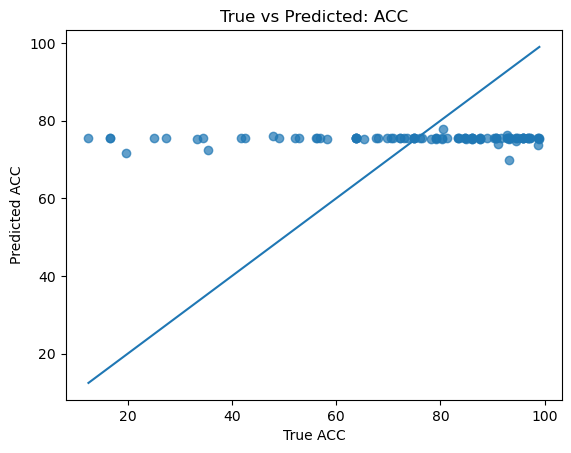

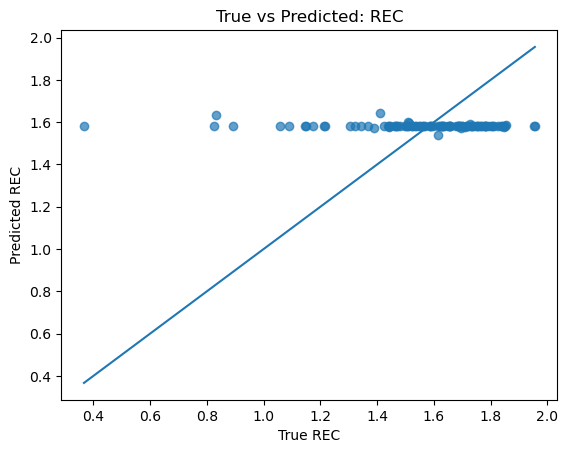

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# ----------------------------
# X: (n_samples, n_features)
# y: (n_samples, 2)  -> columns: [ACC, REC]
# ----------------------------
target_names = ["ACC", "REC"]

# split once for final evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# pipeline + multi-output model
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("model", MultiOutputRegressor(Ridge()))
])

param_grid = {
    "pca__n_components": [0.90, 0.95, 0.98],
    "model__estimator__alpha": np.logspace(-4, 6, 25),
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

search = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

search.fit(X_train, y_train)
best_model = search.best_estimator_

y_pred = best_model.predict(X_test)

print("Best params:", search.best_params_)
for i, name in enumerate(target_names):
    mae = mean_absolute_error(y_test[:, i], y_pred[:, i])
    r2  = r2_score(y_test[:, i], y_pred[:, i])
    print(f"{name}: MAE={mae:.4f}, R2={r2:.4f}")

# ----------------------------
# True vs Pred plots
# ----------------------------
for i, name in enumerate(target_names):
    yt = y_test[:, i]
    yp = y_pred[:, i]

    plt.figure()
    plt.scatter(yt, yp, alpha=0.7)

    # identity line
    lo = min(yt.min(), yp.min())
    hi = max(yt.max(), yp.max())
    plt.plot([lo, hi], [lo, hi])

    plt.xlabel(f"True {name}")
    plt.ylabel(f"Predicted {name}")
    plt.title(f"True vs Predicted: {name}")
    plt.show()


Best params: {'model__estimator__C': 0.1, 'model__estimator__epsilon': 0.01, 'model__estimator__gamma': 'scale'}
Target 1: MAE=15.8171, R2=-0.1138
Target 2: MAE=0.1786, R2=-0.0646


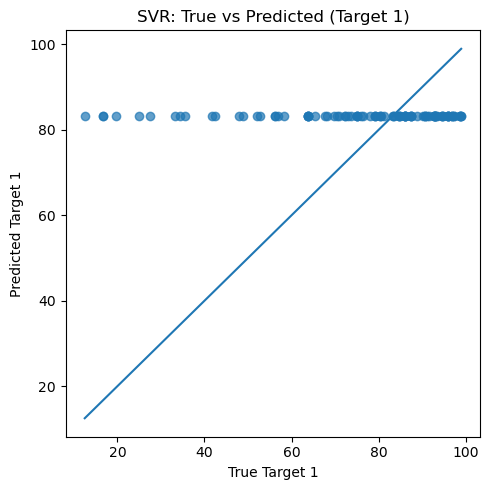

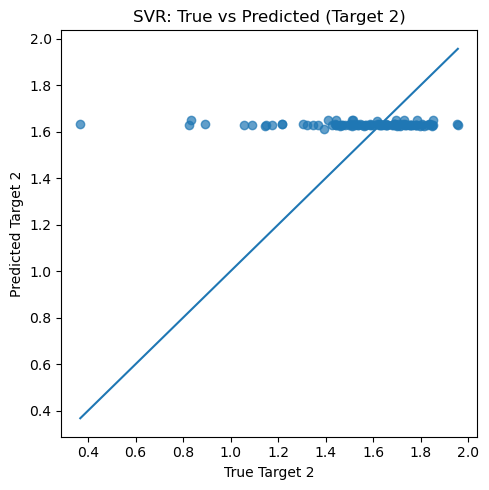

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Ensure y is 2D for unified handling
y_arr = y if y.ndim == 2 else y.reshape(-1, 1)
target_names = [f"Target {i + 1}" for i in range(y_arr.shape[1])]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_arr,
    test_size=0.2,
    random_state=42,
)

base_svr = SVR(kernel="rbf")
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=80)),
    ("model", MultiOutputRegressor(base_svr)),
])

param_grid = {
    "model__estimator__C": [0.1, 1, 10, 100],
    "model__estimator__epsilon": [0.01, 0.1, 0.2],
    "model__estimator__gamma": ["scale", "auto"],
}

search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)

search.fit(X_train, y_train)
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

print("Best params:", search.best_params_)
for i, name in enumerate(target_names):
    mae = mean_absolute_error(y_test[:, i], y_pred[:, i])
    r2 = r2_score(y_test[:, i], y_pred[:, i])
    print(f"{name}: MAE={mae:.4f}, R2={r2:.4f}")

# Plot true vs predicted for each target
for i, name in enumerate(target_names):
    yt = y_test[:, i]
    yp = y_pred[:, i]

    plt.figure(figsize=(5, 5))
    plt.scatter(yt, yp, alpha=0.7)

    lo = min(yt.min(), yp.min())
    hi = max(yt.max(), yp.max())
    plt.plot([lo, hi], [lo, hi])

    plt.xlabel(f"True {name}")
    plt.ylabel(f"Predicted {name}")
    plt.title(f"SVR: True vs Predicted ({name})")
    plt.tight_layout()
    plt.show()

Best n_components: 250
Best mean RT corr: 0.05602270452004297


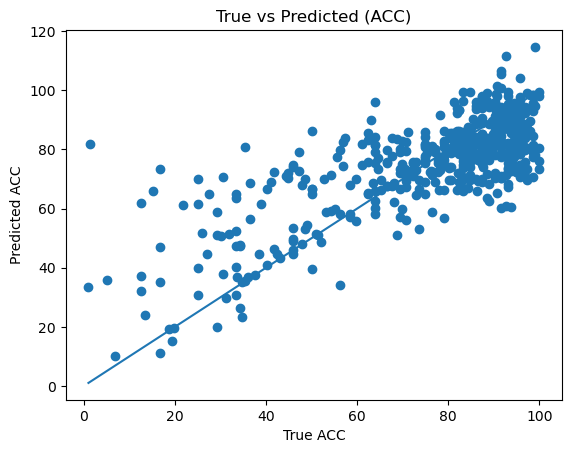

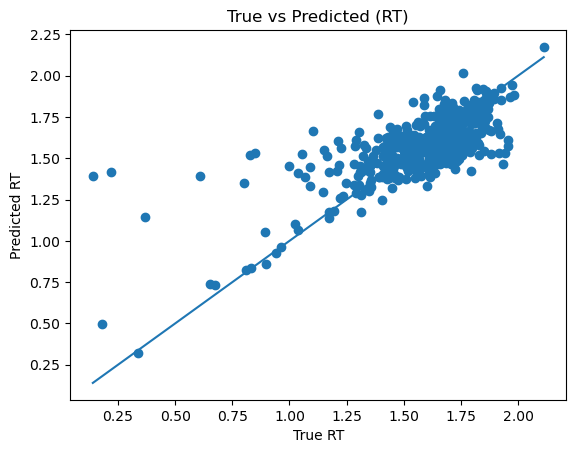

In [14]:
from sklearn.metrics import make_scorer

def rt_corr(y_true, y_pred):
    yt = y_true[:, 1]
    yp = y_pred[:, 1]
    # handle degenerate cases
    if np.std(yt) == 0 or np.std(yp) == 0:
        return np.nan
    return np.corrcoef(yp, yt)[0, 1]

scorer = make_scorer(rt_corr, greater_is_better=True)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),   
    ("ridge", Ridge(alpha=1.0))
])

param_grid = {
    "pca__n_components": [5, 10, 20, 30, 50, 80, 100, 150, 200, 250, 300],
    "ridge__alpha": np.logspace(-4, 6, 10, 20),
    }

cv = KFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    refit=True,          # refit best on full data automatically
)

gs.fit(X, y)

print("Best n_components:", gs.best_params_["pca__n_components"])
print("Best mean RT corr:", gs.best_score_)
best_model = gs.best_estimator_
y_pred = best_model.predict(X)

import matplotlib.pyplot as plt
plt.figure()
plt.scatter(y[:,0], y_pred[:,0])
plt.xlabel("True ACC")
plt.ylabel("Predicted ACC")
plt.title("True vs Predicted (ACC)")
plt.plot([y[:,0].min(), y[:,0].max()],
         [y[:,0].min(), y[:,0].max()])
plt.show()
plt.figure()
plt.scatter(y[:,1], y_pred[:,1])
plt.xlabel("True RT")
plt.ylabel("Predicted RT")
plt.title("True vs Predicted (RT)")
plt.plot([y[:,1].min(), y[:,1].max()],
         [y[:,1].min(), y[:,1].max()])
plt.show()

DE generations:   0%|          | 0/10 [00:00<?, ?gen/s]

Starting differential evolution...
Log every 10 generations


Fatal Python error: Segmentation fault

Current thread 0x00007f6668aa8740 (most recent call first):
  Garbage-collecting
  <no Python frame>

Extension modules: psutil._psutil_linux, psutil._psutil_posix, numpy._core._multiarray_umath, numpy._core._multiarray_tests, numpy.linalg._umath_linalg, sklearn.__check_build._check_build, scipy._lib._ccallback_c, numpy.random._common, numpy.random.bit_generator, numpy.random._bounded_integers, numpy.random._mt19937, numpy.random.mtrand, numpy.random._philox, numpy.random._pcg64, numpy.random._sfc64, numpy.random._generator, charset_normalizer.md, scipy.sparse._sparsetools, _csparsetools, scipy.sparse._csparsetools, scipy.special._ufuncs_cxx, scipy.special._ellip_harm_2, scipy.special._special_ufuncs, scipy.special._gufuncs, scipy.special._ufuncs, scipy.special._specfun, scipy.special._comb, scipy.linalg._fblas, scipy.linalg._flapack, scipy.linalg.cython_lapack, scipy.linalg._cythonized_array_utils, scipy.linalg._solve_toeplitz, scipy.linalg._dec

[log] gen=10 | elapsed=75.81 min | n_components~226 | alpha~7.695e-04 | conv=3.108e-01
FAST_MODE: True
CV splits: 3
Best n_components: 226
Best alpha: 0.0007694962777344504
Best mean RT corr: 0.08772185146470612
Search time: 75.81 min


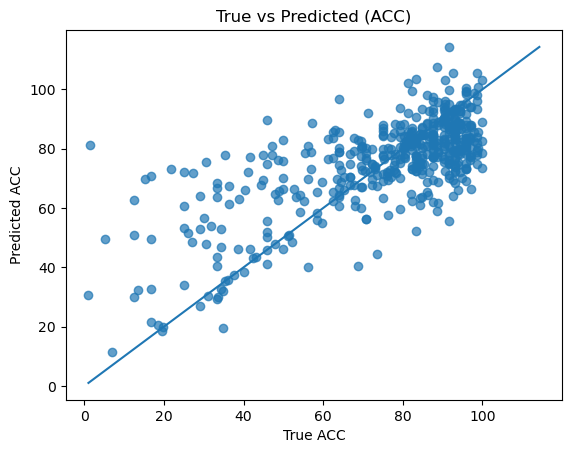

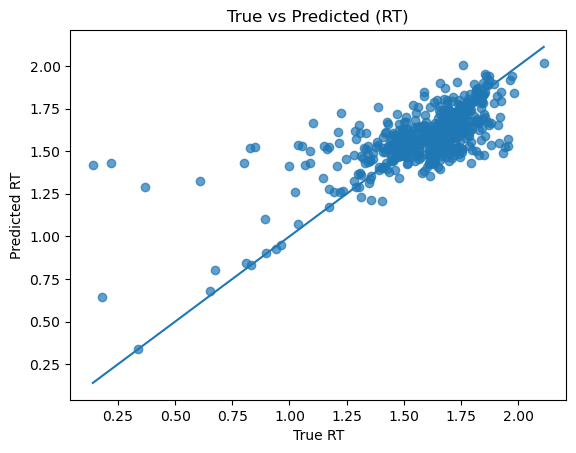

In [15]:
import time
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import differential_evolution
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.metrics import make_scorer
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm


FAST_MODE = True  # Set False for a slower but more thorough search.
CV_SPLITS = 3 if FAST_MODE else 5
DE_MAXITER = 10 if FAST_MODE else 30
DE_POPSIZE = 8 if FAST_MODE else 12
DE_POLISH = False if FAST_MODE else True
LOG_EVERY_GEN = 10


def rt_corr(y_true, y_pred):
    """Return correlation between true and predicted RT (column index 1)."""
    yt = y_true[:, 1]
    yp = y_pred[:, 1]
    if np.std(yt) == 0 or np.std(yp) == 0:
        return 0.0
    return np.corrcoef(yp, yt)[0, 1]


scorer = make_scorer(rt_corr, greater_is_better=True)
cv = KFold(n_splits=CV_SPLITS, shuffle=True, random_state=42)

max_components = int(min(300, X.shape[0] - 1, X.shape[1]))
if max_components < 5:
    raise ValueError(f"Not enough samples/features for PCA search. max_components={max_components}")


def objective(params):
    """Minimize negative CV correlation for RT."""
    n_components_float, log10_alpha = params
    n_components = int(np.clip(np.round(n_components_float), 5, max_components))
    alpha = 10.0 ** log10_alpha

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_components)),
        ("ridge", Ridge(alpha=alpha)),
    ])

    scores = cross_val_score(
        pipe,
        X,
        y,
        scoring=scorer,
        cv=cv,
        n_jobs=1,
        error_score="raise",
    )
    return -float(np.mean(scores))


progress_state = {"start": time.time(), "gen": 0}
pbar = tqdm(total=DE_MAXITER, desc="DE generations", unit="gen", leave=False)


def de_callback(xk, convergence):
    """Update progress bar each generation and log every fixed generation count."""
    progress_state["gen"] += 1
    elapsed = time.time() - progress_state["start"]

    if pbar.n < DE_MAXITER:
        pbar.update(1)

    est_n = int(np.clip(np.round(xk[0]), 5, max_components))
    est_alpha = 10.0 ** xk[1]
    pbar.set_postfix({"n_comp": est_n, "alpha": f"{est_alpha:.2e}"})

    if progress_state["gen"] % LOG_EVERY_GEN == 0:
        print(
            f"[log] gen={progress_state['gen']} | elapsed={elapsed/60:.2f} min "
            f"| n_components~{est_n} | alpha~{est_alpha:.3e} | conv={convergence:.3e}"
        )

    return False


print("Starting differential evolution...")
print(f"Log every {LOG_EVERY_GEN} generations")
start = time.time()
result = differential_evolution(
    func=objective,
    bounds=[(5, max_components), (-4, 6)],
    strategy="best1bin",
    maxiter=DE_MAXITER,
    popsize=DE_POPSIZE,
    tol=1e-2 if FAST_MODE else 1e-3,
    seed=42,
    workers=-1,
    updating="deferred",
    polish=DE_POLISH,
    callback=de_callback,
)
pbar.close()
elapsed = time.time() - start

best_n_components = int(np.clip(np.round(result.x[0]), 5, max_components))
best_alpha = 10.0 ** result.x[1]
best_cv_corr = -result.fun

print("FAST_MODE:", FAST_MODE)
print("CV splits:", CV_SPLITS)
print("Best n_components:", best_n_components)
print("Best alpha:", best_alpha)
print("Best mean RT corr:", best_cv_corr)
print(f"Search time: {elapsed/60:.2f} min")

best_model = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=best_n_components)),
    ("ridge", Ridge(alpha=best_alpha)),
])
best_model.fit(X, y)
y_pred = best_model.predict(X)

plt.figure()
plt.scatter(y[:, 0], y_pred[:, 0], alpha=0.7)
plt.xlabel("True ACC")
plt.ylabel("Predicted ACC")
plt.title("True vs Predicted (ACC)")
acc_lo = min(y[:, 0].min(), y_pred[:, 0].min())
acc_hi = max(y[:, 0].max(), y_pred[:, 0].max())
plt.plot([acc_lo, acc_hi], [acc_lo, acc_hi])
plt.show()

plt.figure()
plt.scatter(y[:, 1], y_pred[:, 1], alpha=0.7)
plt.xlabel("True RT")
plt.ylabel("Predicted RT")
plt.title("True vs Predicted (RT)")
rt_lo = min(y[:, 1].min(), y_pred[:, 1].min())
rt_hi = max(y[:, 1].max(), y_pred[:, 1].max())
plt.plot([rt_lo, rt_hi], [rt_lo, rt_hi])
plt.show()